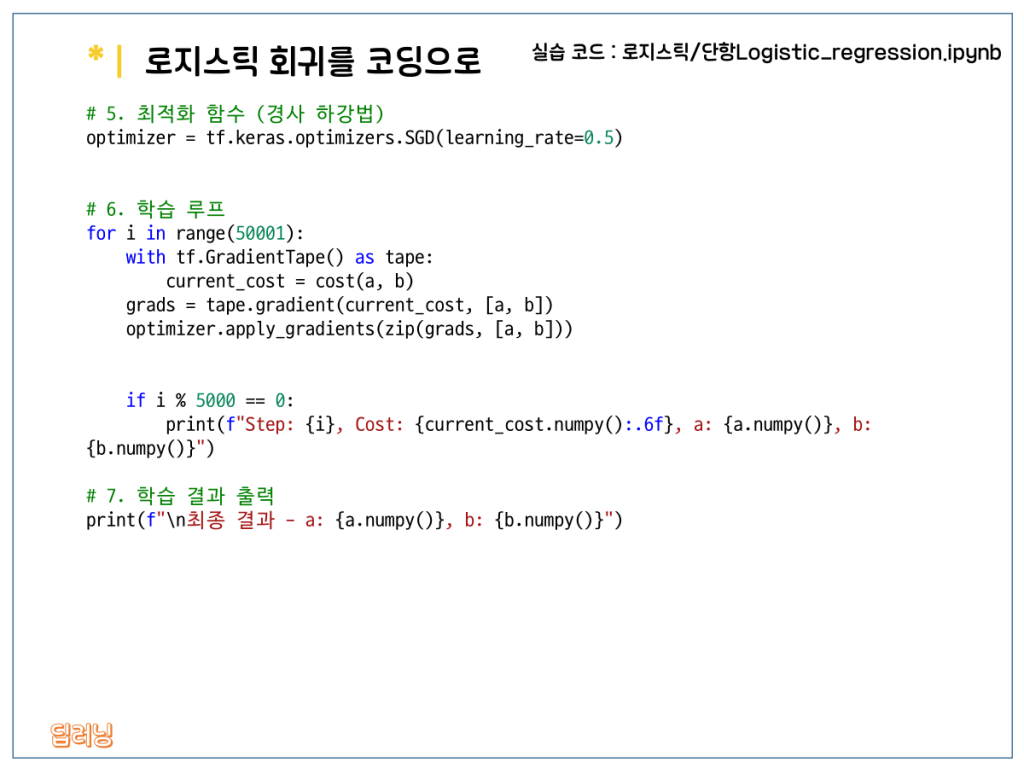

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 공부 시간 -> 시험 합격 여부
data = [[3,0],[6,0],[9,0],[12,1],[15,1],[18,1],[21,1]]
x_data = np.array([x for x, _ in data], dtype=np.float64)
y_data = np.array([y for _, y in data], dtype=np.float64)

a = tf.Variable(tf.random.normal([1],dtype=tf.float64, seed=0))
b = tf.Variable(tf.random.normal([1],dtype=tf.float64, seed=0))

def hypothesis(a, b):
    return 1 / (1 + tf.math.exp(-(a * x_data + b)))

def cost(a, b):
    return -tf.reduce_mean(
        y_data * tf.math.log(hypothesis(a, b) + 1e-7) # 아주 작은 값 1e-7을 붙여줌 = 0이 나왔을 때를 대비
        + (1 - y_data) * tf.math.log(1 - hypothesis(a, b) + 1e-7)
    )

optimizer = tf.keras.optimizers.SGD(learning_rate = 0.5) # 경사하강법 알고리즘 tensor

for i in range(50001):
    with tf.GradientTape() as tape:
        current_cost = cost(a, b)
    grads = tape.gradient(current_cost, [a, b])
    optimizer.apply_gradients(zip(grads, [a, b]))

    if i % 1000 == 0:
        print(f"Step: {i}, Cost: {current_cost.numpy():.6f}, a: {a.numpy()}, b: {b.numpy()}")

print(f"\n최종 결과: a = {a.numpy()}, b = {b.numpy()}")

2026-09-22 22:17:32.788744: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Step: 0, Cost: 6.157738, a: [3.91760189], b: [-0.03064279]
Step: 1000, Cost: 0.033837, a: [1.40197542], b: [-14.55556003]
Step: 2000, Cost: 0.025539, a: [1.59376953], b: [-16.57616349]
Step: 3000, Cost: 0.020506, a: [1.74350705], b: [-18.15210013]
Step: 4000, Cost: 0.017118, a: [1.86649632], b: [-19.44580619]
Step: 5000, Cost: 0.014682, a: [1.97086654], b: [-20.5432815]
Step: 6000, Cost: 0.012847, a: [2.06150309], b: [-21.49611918]
Step: 7000, Cost: 0.011415, a: [2.14158471], b: [-22.3378516]
Step: 8000, Cost: 0.010268, a: [2.21329966], b: [-23.09154493]
Step: 9000, Cost: 0.009328, a: [2.27821983], b: [-23.77375896]
Step: 10000, Cost: 0.008544, a: [2.33751276], b: [-24.39678849]
Step: 11000, Cost: 0.007880, a: [2.39206949], b: [-24.9700134]
Step: 12000, Cost: 0.007311, a: [2.44258545], b: [-25.50075273]
Step: 13000, Cost: 0.006819, a: [2.48961384], b: [-25.99482695]
Step: 14000, Cost: 0.006387, a: [2.53360183], b: [-26.45694058]
Step: 15000, Cost: 0.006007, a: [2.57491607], b: [-26.890

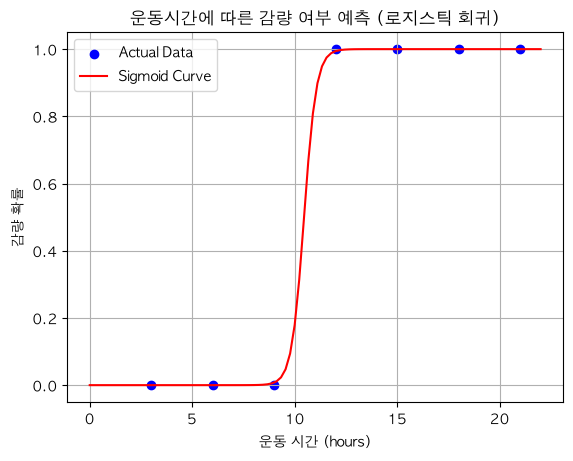

In [2]:
# 8. 시각화
import platform
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import sys; sys.path.append('..')  # mat_kor.py는 저장소 루트에 있음
import mat_kor

# 실제 데이터 시각화
plt.scatter(
    x_data,
    y_data,
    color="blue",
    label="Actual Data"
)

# 시그모이드 곡선을 그릴 x 범위
x_range = np.linspace(0, 22, 100)

# 로지스틱 회귀 예측값 계산
y_pred = 1 / (1 + np.exp(-(a.numpy() * x_range + b.numpy())))

# 시그모이드 곡선 시각화
plt.plot(
    x_range,
    y_pred,
    color="red",
    label="Sigmoid Curve"
)

plt.title("운동시간에 따른 감량 여부 예측 (로지스틱 회귀)")
plt.xlabel("운동 시간 (hours)")
plt.ylabel("감량 확률")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
optimizer_adam = tf.keras.optimizers.Adam(learning_rate = 0.1)

for i in range(5001):
    with tf.GradientTape() as tape:
        current_cost = cost(a, b)
    grads = tape.gradient(current_cost, [a, b])
    optimizer_adam.apply_gradients(zip(grads, [a, b]))

    if i % 500 == 0:ㄹ
        print(f"Step: {i}, Cost: {current_cost.numpy():.6f}, a: {a.numpy()}, b: {b.numpy()}")

print(f"\n최종 결과: a = {a.numpy()}, b = {b.numpy()}")

Step: 0, Cost: 0.001936, a: [3.42333971], b: [-34.9642391]
Step: 500, Cost: 0.000234, a: [4.74481889], b: [-49.68678682]
Step: 1000, Cost: 0.000086, a: [5.4126111], b: [-56.69858357]
Step: 1500, Cost: 0.000044, a: [5.85288875], b: [-61.32148814]
Step: 2000, Cost: 0.000027, a: [6.1926438], b: [-64.88890697]
Step: 2500, Cost: 0.000017, a: [6.47697331], b: [-67.87435757]
Step: 3000, Cost: 0.000012, a: [6.72698668], b: [-70.49948812]
Step: 3500, Cost: 0.000008, a: [6.95421584], b: [-72.88538309]
Step: 4000, Cost: 0.000006, a: [7.16560661], b: [-75.10497323]
Step: 4500, Cost: 0.000004, a: [7.36562644], b: [-77.20516595]
Step: 5000, Cost: 0.000003, a: [7.55728178], b: [-79.21752843]

최종 결과: a = [7.55728178], b = [-79.21752843]


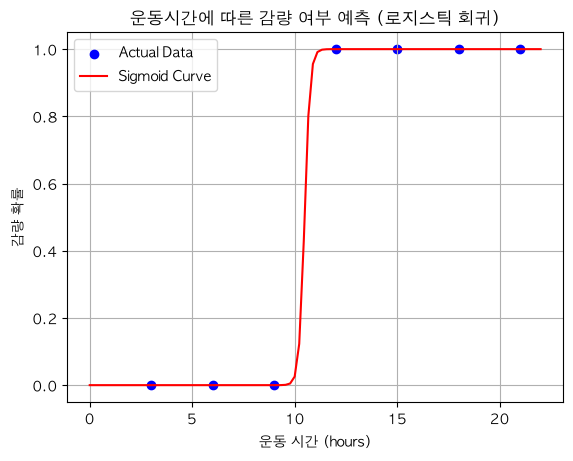

In [4]:
# 실제 데이터 시각화
plt.scatter(
    x_data,
    y_data,
    color="blue",
    label="Actual Data"
)

# 시그모이드 곡선을 그릴 x 범위
x_range = np.linspace(0, 22, 100)

# 로지스틱 회귀 예측값 계산
y_pred = 1 / (1 + np.exp(-(a.numpy() * x_range + b.numpy())))

# 시그모이드 곡선 시각화
plt.plot(
    x_range,
    y_pred,
    color="red",
    label="Sigmoid Curve"
)

plt.title("운동시간에 따른 감량 여부 예측 (로지스틱 회귀)")
plt.xlabel("운동 시간 (hours)")
plt.ylabel("감량 확률")
plt.legend()
plt.grid(True)
plt.show()

로지스틱 회귀 새로운 값 예측

In [5]:
new_x = tf.constant([5.0,16.0,25.0], dtype=tf.float64)

def predict(x, a, b):
    logits = a * x + b
    return 1 / (1 + tf.exp(-logits))

predictions = predict(new_x, a, b)

for x_val, p in zip(new_x.numpy(), predictions.numpy()):
    print(f"x = {x_val:.1f} -> 예측 확률 = {p:.4f} -> 클래스 = {'1' if p >= 0.5 else '0'}")

x = 5.0 -> 예측 확률 = 0.0000 -> 클래스 = 0
x = 16.0 -> 예측 확률 = 1.0000 -> 클래스 = 1
x = 25.0 -> 예측 확률 = 1.0000 -> 클래스 = 1


# 2026.9.23(수) 19h~ 다중 로지스틱 회귀

In [10]:
seed = 0 # seed 값 고정
np.random.seed(seed)
tf.random.set_seed(seed)

x_data = np.array([[3,2.5],[6,2.35],[9,2.3],[12,2.35],[15,2.2],[18,2.25],[21,2.1]], dtype=np.float32)
y_data = np.array([0,0,0,1,1,1,1], dtype=np.float32).reshape(7, 1) # shape=(7,1)로 reshape하는 이유 이해하기

W = tf.Variable(tf.random.uniform([2,1], dtype=tf.float32))
b = tf.Variable(tf.random.uniform([1], dtype=tf.float32))

def hypothesis(W, b):
    return tf.sigmoid(tf.matmul(x_data, W) + b) # 행렬 곱

def costFunc():
    return - tf.reduce_mean(y_data * tf.math.log(hypothesis(W, b)) + (1 - y_data) * tf.math.log(1 - hypothesis(W, b)))

opt = tf.keras.optimizers.SGD(learning_rate=0.1)

for i in range(2001):
    with tf.GradientTape() as tape:
        current_cost = costFunc()
    grads = tape.gradient(current_cost, [W,b])
    opt.apply_gradients(zip(grads, [W,b]))
    if i % 200 == 0:
        print(f'epochs={i}, cost={current_cost.numpy()}, W1={W.numpy()[0,0]}, W2={W.numpy()[1,0]}, b={b.numpy()}')

print("\n==학습 결과?=====================")
print("W = ", W.numpy())
print("b = ", b.numpy()[0])
print("y_data = ", y_data)

new_x = np.array([[3,2.5],[6,2.35],[9,2.3],[12,2.35],[15,2.2],[18,2.25],[21,2.1]], dtype=np.float32)

def predict(x):
    return tf.sigmoid(tf.matmul(x, W) + b)

pred_prob = predict(new_x).numpy()

pred_class = (pred_prob > 0.5).astype(int)

print("\n==예측 결과=====================")
for i in range(len(new_x)):
    print(f"입력 {new_x[i]} -> 확률 = {pred_prob[i, 0]:.4f}, 예측 클래스 = {pred_class[i,0]}")

epochs=0, cost=1.233536958694458, W1=0.05186009407043457, W2=0.11222440749406815, b=[0.51577675]
epochs=200, cost=0.12693651020526886, W1=0.5854682922363281, W2=-2.322869300842285, b=[-0.49944752]
epochs=400, cost=0.09230345487594604, W1=0.7740203142166138, W2=-3.0549535751342773, b=[-0.8242927]
epochs=600, cost=0.07557328790426254, W1=0.9074485898017883, W2=-3.565626382827759, b=[-1.0554137]
epochs=800, cost=0.06483528763055801, W1=1.014954686164856, W2=-3.9746711254119873, b=[-1.2424563]
epochs=1000, cost=0.057081472128629684, W1=1.106551170349121, W2=-4.322100639343262, b=[-1.4022954]
epochs=1200, cost=0.05111279338598251, W1=1.1870341300964355, W2=-4.626802444458008, b=[-1.5430285]
epochs=1400, cost=0.04632987827062607, W1=1.259148359298706, W2=-4.899481296539307, b=[-1.6693052]
epochs=1600, cost=0.04238944500684738, W1=1.3246463537216187, W2=-5.146928787231445, b=[-1.7841119]
epochs=1800, cost=0.03907594457268715, W1=1.384737253189087, W2=-5.373803615570068, b=[-1.8895136]
epochs=

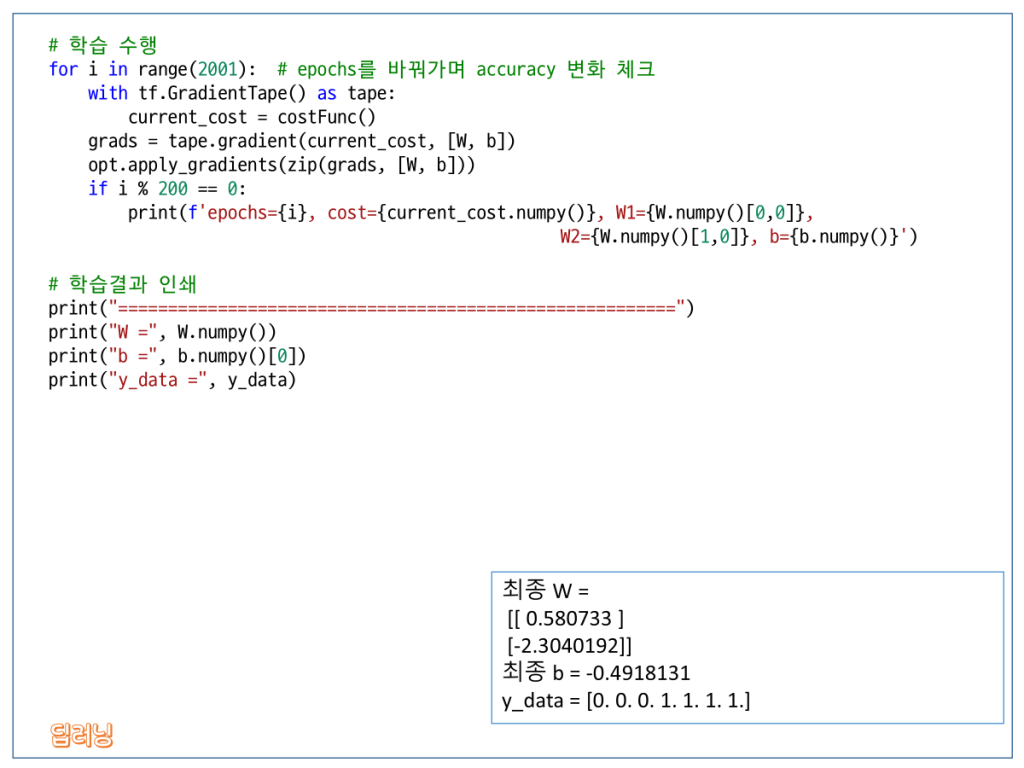


==예측 결과=====================
입력 [3.  2.5] -> 확률 = 0.0000, 예측 클래스 = 0
입력 [6.   2.35] -> 확률 = 0.0016, 예측 클래스 = 0
입력 [9.  2.3] -> 확률 = 0.1340, 예측 클래스 = 0
입력 [12.    2.35] -> 확률 = 0.8980, 예측 클래스 = 1
입력 [15.   2.2] -> 확률 = 0.9993, 예측 클래스 = 1
입력 [18.    2.25] -> 확률 = 1.0000, 예측 클래스 = 1
입력 [21.   2.1] -> 확률 = 1.0000, 예측 클래스 = 1


epochs=0, cost=1.233536958694458, accuracy=0.5714285714285714, W1=0.05186009407043457, W2=0.11222440749406815, b=[0.51577675]
epochs=200, cost=0.12693651020526886, accuracy=1.0, W1=0.5854682922363281, W2=-2.322869300842285, b=[-0.49944752]
epochs=400, cost=0.09230345487594604, accuracy=1.0, W1=0.7740203142166138, W2=-3.0549535751342773, b=[-0.8242927]
epochs=600, cost=0.07557328790426254, accuracy=1.0, W1=0.9074485898017883, W2=-3.565626382827759, b=[-1.0554137]
epochs=800, cost=0.06483528763055801, accuracy=1.0, W1=1.014954686164856, W2=-3.9746711254119873, b=[-1.2424563]
epochs=1000, cost=0.057081472128629684, accuracy=1.0, W1=1.106551170349121, W2=-4.322100639343262, b=[-1.4022954]
epochs=1200, cost=0.05111279338598251, accuracy=1.0, W1=1.1870341300964355, W2=-4.626802444458008, b=[-1.5430285]
epochs=1400, cost=0.04632987827062607, accuracy=1.0, W1=1.259148359298706, W2=-4.899481296539307, b=[-1.6693052]
epochs=1600, cost=0.04238944500684738, accuracy=1.0, W1=1.3246463537216187, W2=

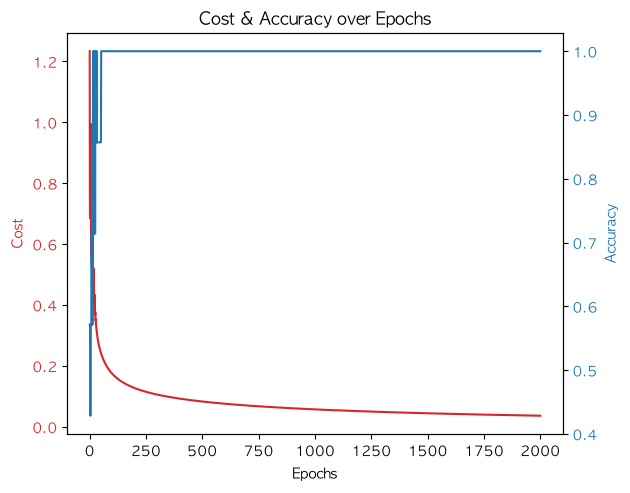


==학습 결과=====================
W =  [[ 1.4402978]
 [-5.583472 ]]
b =  -1.9870212
y_data =  [[0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]]
sigmoid =  [[8.9414189e-06]
 [1.5524094e-03]
 [1.3396750e-01]
 [8.9801794e-01]
 [9.9934733e-01]
 [9.9998856e-01]
 [9.9999994e-01]]
predicted =  [[0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]]
accuracy =  1.0

==예측 결과=====================
운동 시간: 13, 야식 스코어: 2
감량 가능성:  98.85 %
예측 결과:  감량


In [20]:
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

x_data = np.array([[3,2.5],[6,2.35],[9,2.3],[12,2.35],[15,2.2],[18,2.25],[21,2.1]], dtype=np.float32)
y_data = np.array([0,0,0,1,1,1,1], dtype=np.float32).reshape(7, 1) # shape=(7,1)로 reshape하는 이유 이해하기

W = tf.Variable(tf.random.uniform([2,1], dtype=tf.float32))
b = tf.Variable(tf.random.uniform([1], dtype=tf.float32))

def hypothesis(W, b):
    return tf.sigmoid(tf.matmul(x_data, W) + b) # 행렬 곱

def costFunc():
    return - tf.reduce_mean(y_data * tf.math.log(hypothesis(W, b)) + (1 - y_data) * tf.math.log(1 - hypothesis(W, b)))

opt = tf.keras.optimizers.SGD(learning_rate=0.1)
epoch_arr = []
cost_arr = []
accuracy_arr = []

# 코드가 즉시 실행되도록 임의의 더미 데이터를 추가했습니다.
# 실제 학습 루프에서 생성된 리스트나 배열을 사용하세요.
# epoch_arr = [1, 2, 3, 4, 5]
# cost_arr = [0.8, 0.6, 0.4, 0.3, 0.2]
# accuracy_arr = [0.5, 0.65, 0.75, 0.85, 0.9]

def graph(): #
    fig, ax1 = plt.subplots() 

    ax1.set_xlabel('Epochs') 
    ax1.set_ylabel('Cost', color='tab:red') 
    ax1.plot(epoch_arr, cost_arr, color='tab:red', label='Cost') 
    ax1.tick_params(axis='y', labelcolor='tab:red') 

    ax2 = ax1.twinx()  # x축 공유
    ax2.set_ylabel('Accuracy', color='tab:blue') 
    ax2.plot(epoch_arr, accuracy_arr, color='tab:blue', label='Accuracy') 
    ax2.tick_params(axis='y', labelcolor='tab:blue') 

    fig.tight_layout() 
    plt.title("Cost & Accuracy over Epochs") 
    plt.show() 

for i in range(2001):
    with tf.GradientTape() as tape:
        current_cost = costFunc()
    grads = tape.gradient(current_cost, [W,b])
    opt.apply_gradients(zip(grads, [W,b]))
    
    predicted = tf.cast(hypothesis(W, b) > 0.5, dtype=tf.float32) # true 1.0 vs false 0.0(실수)
    epoch_arr.append(i)
    cost_arr.append(current_cost.numpy())
    accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted, y_data), dtype=tf.float64))
    accuracy_arr.append(accuracy)

    if i % 200 == 0:
        print(f'epochs={i}, cost={current_cost.numpy()}, accuracy={accuracy.numpy()}, W1={W.numpy()[0,0]}, W2={W.numpy()[1,0]}, b={b.numpy()}')
    
graph()

print("\n==학습 결과=====================")
print("W = ", W.numpy())
print("b = ", b.numpy()[0])
print("y_data = ", y_data)
print("sigmoid = ", hypothesis(W, b).numpy())
print("predicted = ", predicted.numpy())
print("accuracy = ", accuracy.numpy())

def logistic_predict(X):
    z = tf.matmul(X,W) + b
    return tf.sigmoid(z)

new_x = np.array([13.0, 2.2], dtype=np.float32).reshape(1,2) # reshape(1,2) = deep learning 모델링에서 중요, 지금 학습시킨 모델은 학습할 때 2차원 배열이 입력되었기 때문에(x_data) 새로운 데이터/예측 데이터도 동일한 treat/차원이어야 함 
new_x_tensor = tf.constant(new_x, dtype=tf.float32) # tensorflow 상수로 만듦

new_y = logistic_predict(new_x_tensor)
new_y_result = tf.cast(new_y > 0.5, dtype=tf.int32) # true 1 or false 0

print("\n==예측 결과=====================")
print("운동 시간: %d, 야식 스코어: %d" % (new_x[0][0], new_x[0][1]))
print("감량 가능성: %6.2F %%" % (new_y.numpy()[0][0] * 100))
print("예측 결과: ", "감량" if new_y_result.numpy()[0][0] == 1 else "감량 실패") # 3항 비교에 사용된 if 조건문

In [23]:
new_x = np.array([[7,2.5],[13,2],[17,1.5]], dtype=np.float32).reshape(3,2) # [[7,2.5],[13,2],[17,1.5]] 자체가 이미 2차원이라 굳이 reshape 안 해도 됨
new_x_tensor = tf.constant(new_x, dtype=tf.float32) # tensorflow 상수로 만듦, 단 명시적 형 변환 안 해줘도 됨, numpy array 전달해줘도 동작함, like array를 전달하면 된다

new_y = logistic_predict(new_x_tensor)
new_y_result = tf.cast(new_y > 0.5, dtype=tf.int32) # true 1 or false 0

for i in range(len(new_x)):
    print("\n==예측 결과=====================")
    print("운동 시간: %d, 야식 스코어: %d" % (new_x[i][0], new_x[i][1]))
    print("감량 가능성: %6.2F %%" % (new_y.numpy()[i][0] * 100))
    print("예측 결과: ", "감량" if new_y_result.numpy()[i][0] == 1 else "감량 실패") # 3항 비교에 사용된 if 조건문


==예측 결과=====================
운동 시간: 7, 야식 스코어: 2
감량 가능성:   0.28 %
예측 결과:  감량 실패

==예측 결과=====================
운동 시간: 13, 야식 스코어: 2
감량 가능성:  99.62 %
예측 결과:  감량

==예측 결과=====================
운동 시간: 17, 야식 스코어: 1
감량 가능성: 100.00 %
예측 결과:  감량


In [ ]:
# new_x_tensor = tf.constant(np.array([13.0, 2,2], dtype=np.float32).reshape(1,2), dtype=tf.float32)

# new_y = logistic_predict(new_x_tensor)
# new_y_result = tf.cast(new_y > 0.5, dtype=tf.int32)

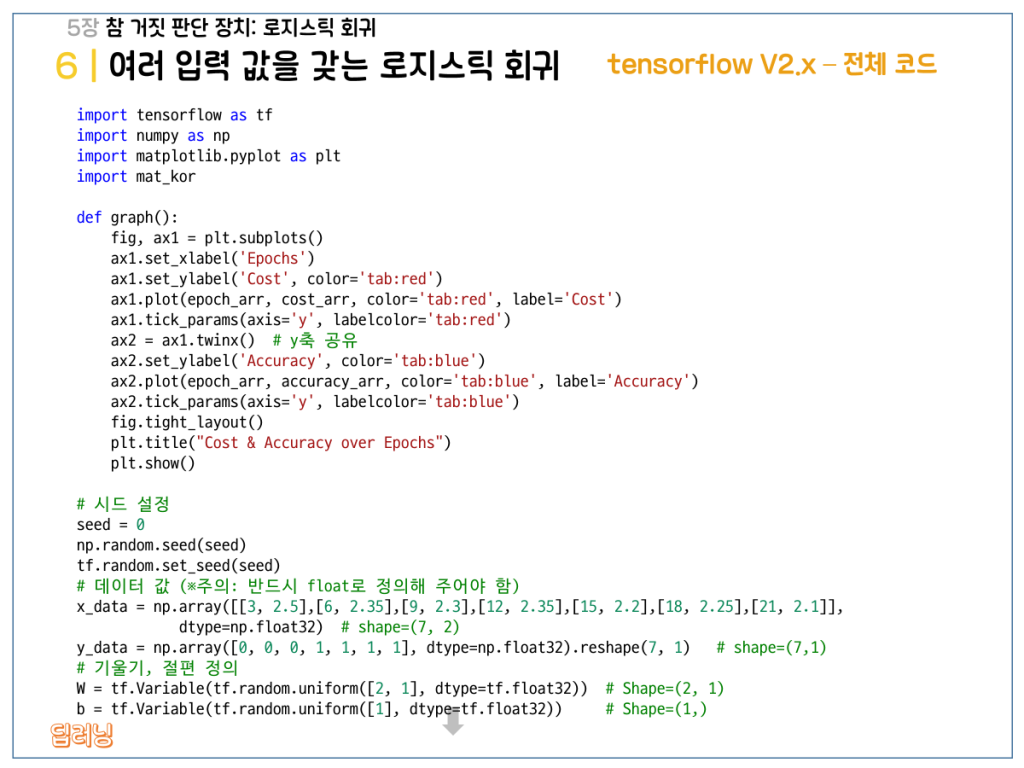
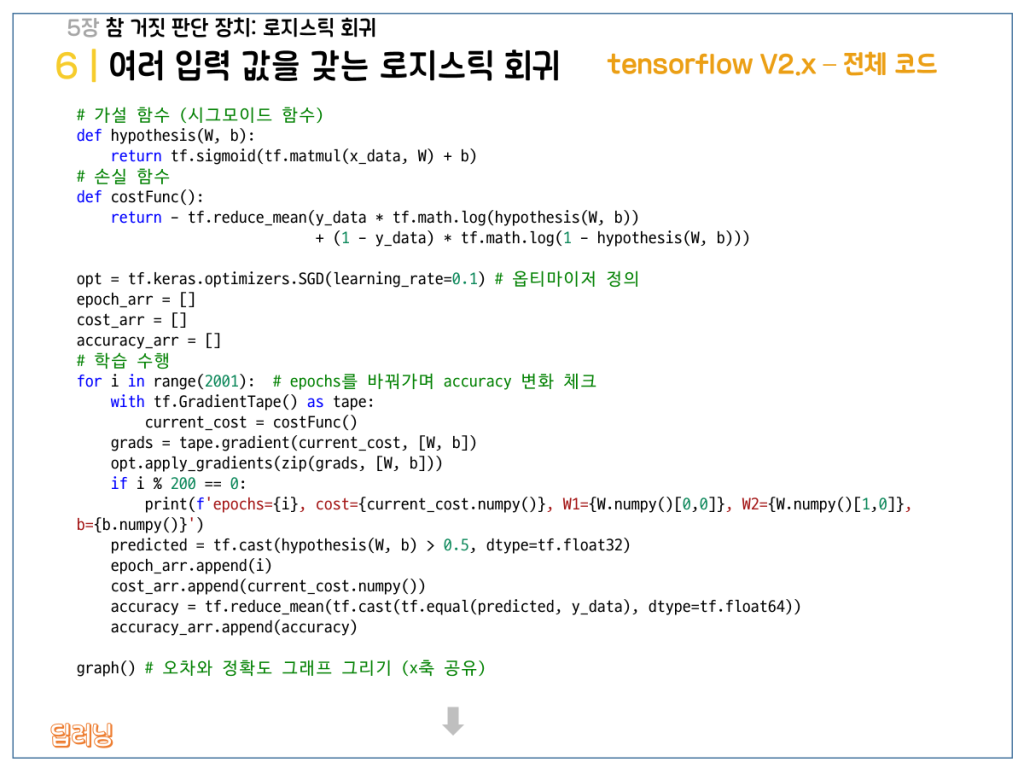
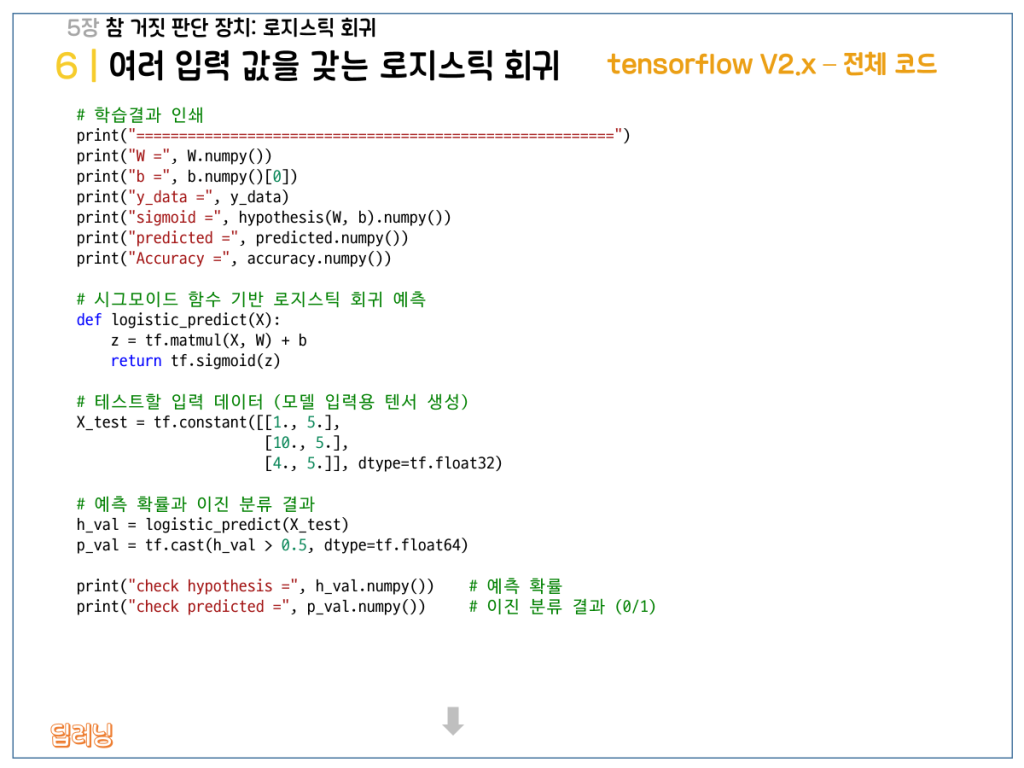

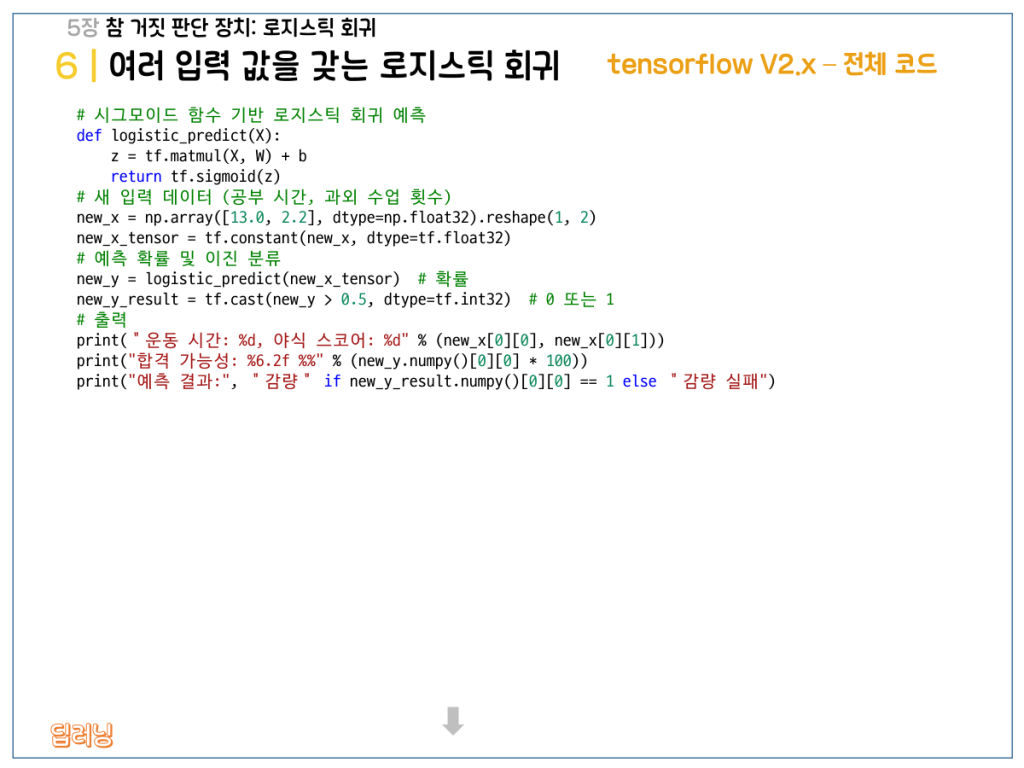

In [16]:
# print("accuracy_arr = ", accuracy_arr.numpy())

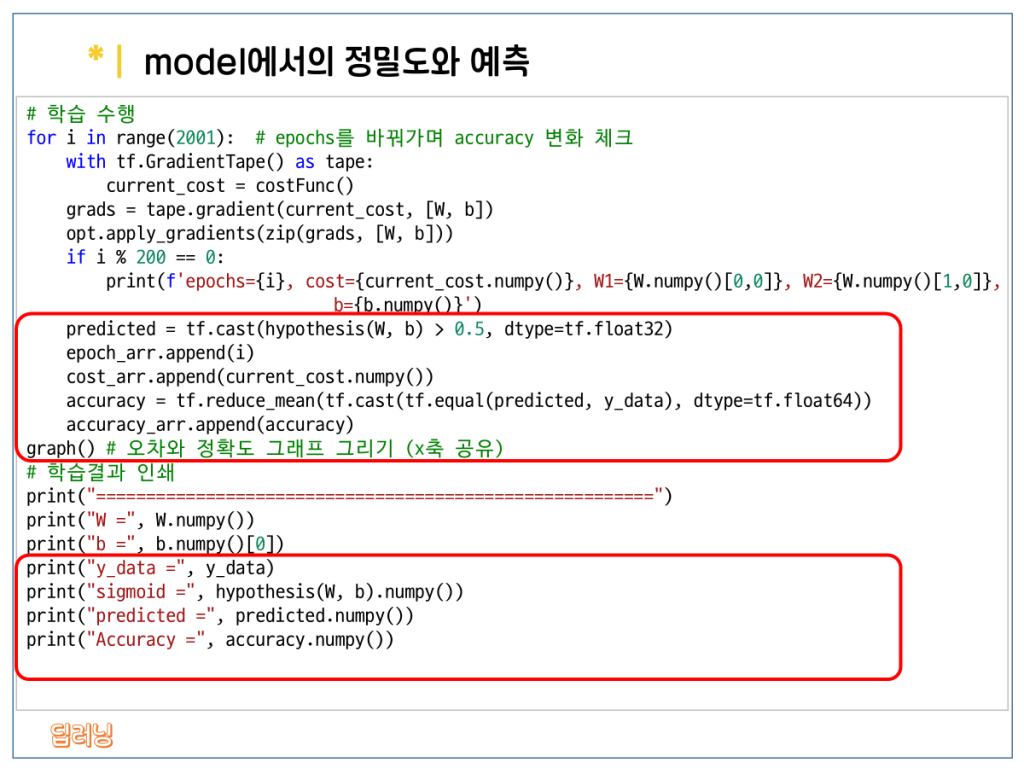